In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv to Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv")

In [ ]:
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [ ]:
print ("shape of dataset:",df.shape)

shape of dataset: (6000, 20)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [ ]:
print(df.columns)

Index(['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id',
       'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity',
       'price', 'payment_method', 'order_frequency', 'last_order_date',
       'loyalty_points', 'churned', 'rating', 'rating_date', 'delivery_status',
       'total_sales'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64


In [ ]:
df = df.fillna(0)
print(df.isnull().sum())

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64


In [ ]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()
print("Duplicate rows After removal:",df.duplicated().sum())

Duplicate rows After removal: 0


In [ ]:
df["total_sales"] = df["price"]* df ["quantity"]
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,total_sales
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled,7391.35
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,2868.12
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,1765.02
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,925.20
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled,1156.69


In [ ]:
top_3 = df.groupby("dish_name")["total_sales"].sum().sort_values(ascending=False).head(3)
print(top_3)

dish_name
Pasta       3078850.36
Sandwich    2966591.11
Pizza       2782227.05
Name: total_sales, dtype: float64


In [ ]:
average_rating = df.groupby("dish_name")["rating"].mean()
print(average_rating)

dish_name
Burger      3.012248
Fries       3.002604
Pasta       3.008716
Pizza       2.921667
Sandwich    3.037812
Name: rating, dtype: float64


In [ ]:
print(average_rating.round(2))

category
Chinese        3.01
Continental    3.00
Dessert        3.05
Fast Food      2.95
Italian        2.98
Name: rating, dtype: float64


In [ ]:
def rating_category(rating_label):
  if rating_label  >= 4.5:
    return "Excellent"
  elif rating_label >= 4.0:
    return "Good"
  elif rating_label >= 3:
    return "Average"
  else:
    return "Poor"

In [ ]:
df["rating_label"] = df["rating"].apply(rating_category)
display(df[["rating", "rating_label"]].head())

,rating,rating_label
0,3,Average
1,2,Poor
2,3,Average
3,2,Poor
4,3,Average


PART C:

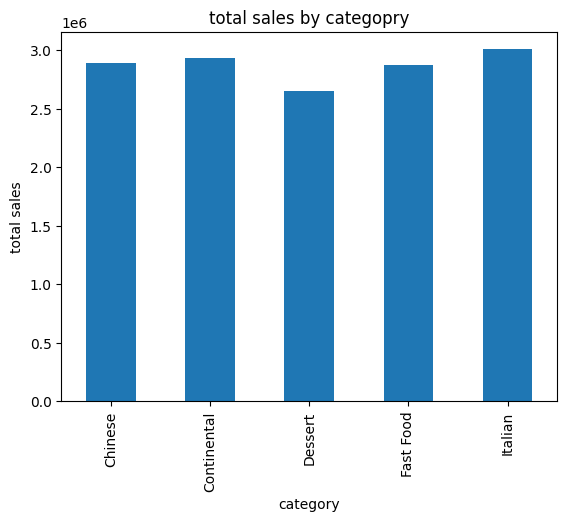

In [ ]:
sales_category = df.groupby("category")["total_sales"].sum()
sales_category.plot(kind="bar")
plt.title("total sales by categopry")
plt.xlabel("category")
plt.ylabel("total sales")
plt.show()

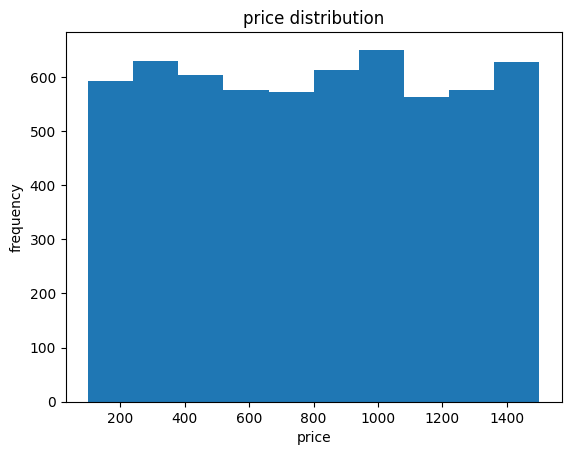

In [ ]:
plt.hist(df["price"],bins=10)
plt.title("price distribution")
plt.xlabel("price")
plt.ylabel("frequency")
plt.show()

In [ ]:
print("Mean:",df["total_sales"].mean())
print("Median:",df["total_sales"].median())
print("Standard Deviation:",df["total_sales"].std())

Mean: 2390.6520133333333
Median: 1901.5749999999998
Standard Deviation: 1754.874758108934


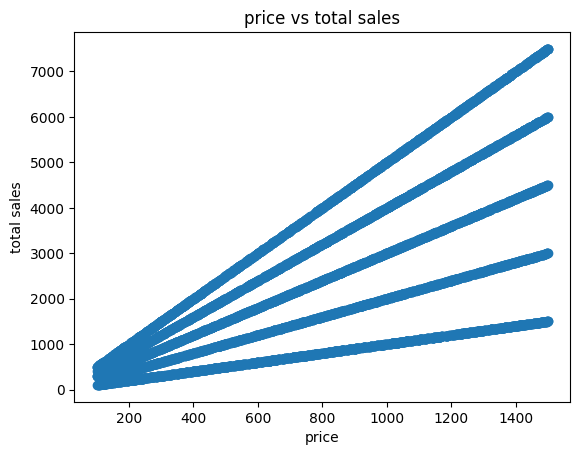

In [ ]:
plt.scatter(df["price"],df["total_sales"])
plt.title("price vs total sales")
plt.xlabel("price")
plt.ylabel("total sales")
plt.show()

PART D:

In [ ]:
X = df[["price","quantity","order_frequency"]]
Y = df["total_sales"]
print(X.head())
print(Y.head())

     price  quantity  order_frequency
0  1478.27         5               38
1   956.04         3               24
2   882.51         2               42
3   231.30         4               27
4  1156.69         1               35
0    7391.35
1    2868.12
2    1765.02
3     925.20
4    1156.69
Name: total_sales, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("training rows:"),len(X_train)
print("testing rows:"),len(X_test)

training rows:
testing rows:


(None, 1200)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [ ]:
model.fit(X_train, Y_train)
print("model trained successfully!")

model trained successfully!


In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[3176.31541385 2253.41771899 -122.78192297 ... 2773.84141533 1895.26425412
 -148.58523389]


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

R-squared: 0.8935614191167981
Mean Absolute Error: 412.1652062676387


In [ ]:
results = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": y_pred
})
results.head(10)

,Actual,Predicted
1782,2632.55,3176.315414
3917,2267.52,2253.417719
221,452.02,-122.781923
2135,3884.13,3866.602624
5224,359.52,-511.895685
1168,1596.30,1594.123518
879,664.56,658.028837
156,1946.55,1939.170186
1657,951.59,1252.842375
323,1564.60,1537.378243


In [ ]:
The model predicts total sales fairly well based on price, quantity, and order frequency.
A higher R² means the model explains more of the changes in total sales.
A lower MAE means the model predictions are closer to the actual sales values.